In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from collections import Counter

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import CountVectorizer
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

LABEL2ID = {"ENHANCER": 0, "PROMOTER": 1, "INTERGENIC": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
LABEL_MAP = ["ENHANCER", "PROMOTER", "INTERGENIC"]

In [ ]:
def load_and_analyze(parquet_path):
    print("--- Loading Data ---")
    df = pd.read_parquet(parquet_path, engine='fastparquet')
    
    X = df['sequence'].tolist()
    y = df['label'].values
    
    lengths = [len(s) for s in X]
    limit_95 = int(np.percentile(lengths, 95))
    print(f"Average Length: {np.mean(lengths):.2f}")
    print(f"Max Length in data: {max(lengths)}")
    print(f"95th Percentile Length: {limit_95}") #(Recommended for CNN padding)
    
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.15, random_state=42, stratify=y
    )
    
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
    )
    
    print(f"Dataset Split:")
    print(f"  Train: {len(X_train)} samples")
    print(f"  Val:   {len(X_val)} samples (Static validation)")
    print(f"  Test:  {len(X_test)} samples (Held-out)")
    
    return X_train, X_val, X_test, y_train, y_val, y_test, limit_95

path = './unified_DNA_dataset/DNA_multiclass_balanced.parquet'
X_train, X_val, X_test, y_train, y_val, y_test, RECOMMENDED_LEN = load_and_analyze(path)

--- Loading Data ---
Average Length: 240.17
Max Length in data: 573
95th Percentile Length: 396 (Recommended for CNN padding)
Dataset Split:
  Train: 75918 samples
  Val:   16216 samples (Static validation)
  Test:  16259 samples (Held-out)


In [ ]:
print("\n--- Step 2: SVM Optimization with Optuna ---")
optuna.logging.set_verbosity(optuna.logging.WARNING)

subset_idx = np.random.choice(len(X_train), size=15000, replace=False)
X_train_sub = [X_train[i] for i in subset_idx]
y_train_sub = y_train[subset_idx]

def objective(trial):
    k_mer = trial.suggest_int('k_mer', 3, 6) # גודל ה-K-mer
    c_param = trial.suggest_float('C', 1e-3, 10, log=True) # רגולריזציה
    
    # K-mer
    vectorizer = CountVectorizer(analyzer='char', ngram_range=(k_mer, k_mer))
    X_vec = vectorizer.fit_transform(X_train_sub)
    
    # Validation
    X_tr, X_val, y_tr, y_val = train_test_split(X_vec, y_train_sub, test_size=0.25, random_state=42)
    
    # LinearSVC (non-linear SVM was way too heavy for tuning on this dataset)
    clf = LinearSVC(C=c_param, dual=False, max_iter=2000)
    clf.fit(X_tr, y_tr)
    
    return clf.score(X_val, y_val)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15) # מריץ 15 ניסויים

print(f"Best Params: {study.best_params}")

print("\nTraining Final SVM on FULL dataset...")
best_k = study.best_params['k_mer']
best_c = study.best_params['C']

# וקטוריזציה
final_vec = CountVectorizer(analyzer='char', ngram_range=(best_k, best_k))
X_train_svm = final_vec.fit_transform(X_train)
X_test_svm = final_vec.transform(X_test)

svm_model = LinearSVC(C=best_c, dual=False, verbose=1)
svm_model.fit(X_train_svm, y_train)

y_pred_svm = svm_model.predict(X_test_svm)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Final Accuracy: {acc_svm:.4f}")


--- Step 2: SVM Optimization with Optuna ---
Best Params: {'k_mer': 6, 'C': 0.0011133704559181587}

Training Final SVM on FULL dataset...
[LibLinear]iter  1 act 3.598e+01 pre 3.515e+01 delta 6.549e-01 f 8.452e+01 |g| 2.753e+02 CG   6
cg reaches trust region boundary
iter  2 act 4.153e+00 pre 3.860e+00 delta 7.127e-01 f 4.854e+01 |g| 2.917e+01 CG   9
iter  3 act 8.756e-01 pre 8.473e-01 delta 7.127e-01 f 4.439e+01 |g| 8.449e+00 CG  19
iter  4 act 3.853e-02 pre 3.764e-02 delta 7.127e-01 f 4.351e+01 |g| 2.113e+00 CG  19
iter  5 act 3.273e-03 pre 3.200e-03 delta 7.127e-01 f 4.347e+01 |g| 3.127e-01 CG  21
iter  6 act 1.869e-04 pre 1.869e-04 delta 7.127e-01 f 4.347e+01 |g| 4.591e-02 CG  25
iter  1 act 3.038e+01 pre 2.999e+01 delta 7.542e-01 f 8.452e+01 |g| 2.712e+02 CG   7
cg reaches trust region boundary
iter  2 act 4.029e+00 pre 3.955e+00 delta 7.722e-01 f 5.415e+01 |g| 2.172e+01 CG  10
iter  3 act 6.383e-01 pre 6.288e-01 delta 7.722e-01 f 5.012e+01 |g| 7.944e+00 CG  20
iter  4 act 1.962e-

In [20]:
print(f"SVM Final Accuracy: {acc_svm:.4f}")

SVM Final Accuracy: 0.7283


In [26]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.utils.class_weight import compute_class_weight

# --- 1. Preprocessing Functions ---
DNA_DICT = {'A': 0, 'C': 1, 'G': 2, 'T': 3, 'N': 4} 

def encode_and_pad(sequences, max_len):
    encoded_list = []
    for seq in sequences:
        num_seq = [DNA_DICT.get(base, 4) for base in seq] 
        encoded_list.append(num_seq)
    # Padding
    return pad_sequences(encoded_list, maxlen=max_len, padding='post', truncating='post', value=4)

# --- 2. Augmentation Functions ---
def augment_dna_simple(seq_ohe, label):
    """Adds noise to DNA sequence for robustness"""
    seq_ohe = tf.cast(seq_ohe, tf.float32)
    noise = tf.random.normal(tf.shape(seq_ohe), mean=0.0, stddev=0.02, dtype=tf.float32)
    seq_ohe = seq_ohe + noise
    seq_ohe = tf.clip_by_value(seq_ohe, 0.0, 1.0)
    return seq_ohe, label

def create_augmented_dataset(X, y, batch_size=32, augment=True, shuffle=True):
    # Ensure correct types
    X = X.astype(np.float32)
    y = y.astype(np.float32)
    
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=10000, reshuffle_each_iteration=True)
    
    if augment:
        dataset = dataset.map(augment_dna_simple, num_parallel_calls=tf.data.AUTOTUNE)
    
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

# --- 3. Model Definition ---
def build_dna_cnn_robust(seq_length, num_classes=3):
    model = models.Sequential([
        layers.GaussianNoise(0.1, input_shape=(seq_length, 5)),
        
        layers.Conv1D(filters=32, kernel_size=12, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.0001, l2=0.001)),
        layers.BatchNormalization(),
        layers.SpatialDropout1D(0.2),
        layers.MaxPooling1D(pool_size=4),
        
        layers.Conv1D(filters=64, kernel_size=8, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.0001, l2=0.001)),
        layers.BatchNormalization(),
        layers.SpatialDropout1D(0.3),
        layers.MaxPooling1D(pool_size=4),
        
        layers.Conv1D(filters=32, kernel_size=6, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.0001, l2=0.001)),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        
        layers.Dense(64, activation='relu',
                    kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.0001, l2=0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003, clipnorm=1.0),
        loss='categorical_crossentropy', # הסרתי label_smoothing זמנית כדי למנוע התנגשות עם שמות מטריקות, ניתן להחזיר
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

print("All functions defined successfully.")

All functions defined successfully.


In [ ]:
from sklearn.model_selection import StratifiedKFold
# 1. הכנת הדאטה (שימוש בפונקציה מתא 1)
# המשתנים X_train, X_val, y_train וכו' מגיעים מפונקציית load_and_analyze שהגדרנו קודם
FINAL_LEN = max(RECOMMENDED_LEN, 200)

# איחוד Train ו-Val לצורך ה-Cross Validation
X_cv_raw = X_train + X_val
y_cv_raw = np.concatenate([y_train, y_val])

print("Encoding data...")
X_cv_padded = encode_and_pad(X_cv_raw, FINAL_LEN)
X_test_padded = encode_and_pad(X_test, FINAL_LEN)

# המרה ל-One-Hot
X_cv_ohe = tf.one_hot(X_cv_padded, depth=5).numpy()
X_test_ohe = tf.one_hot(X_test_padded, depth=5).numpy()
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=3)

# הרצת Cross-Validation
n_splits = 5
kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
cv_scores = []
best_val_acc = 0
best_model = None

In [28]:
print(f"\n--- Starting {n_splits}-Fold Cross-Validation ---\n")

for i, (train_idx, val_idx) in enumerate(kfold.split(X_cv_ohe, y_cv_raw)):
    print(f"Fold {i+1}/{n_splits}...", end="")
    
    # חלוקה ל-Fold הנוכחי
    X_f_tr, X_f_val = X_cv_ohe[train_idx], X_cv_ohe[val_idx]
    y_f_tr, y_f_val = y_cv_raw[train_idx], y_cv_raw[val_idx]
    
    # המרה ל-Categorical
    y_f_tr_cat = tf.keras.utils.to_categorical(y_f_tr, num_classes=3)
    y_f_val_cat = tf.keras.utils.to_categorical(y_f_val, num_classes=3)
    
    # יצירת Datasets עם אוגמנטציה (מתא 3)
    train_ds = create_augmented_dataset(X_f_tr, y_f_tr_cat, batch_size=32, augment=True)
    val_ds = create_augmented_dataset(X_f_val, y_f_val_cat, batch_size=32, augment=False, shuffle=False)
    
    # בניית מודל נקי (מתא 2)
    model = build_dna_cnn_robust(seq_length=FINAL_LEN, num_classes=3)
    
    # הגדרת Callbacks לכל Fold (מתא 4)
    fold_callbacks = [
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
    ]
    
    # אימון
    history = model.fit(
        train_ds, validation_data=val_ds,
        epochs=30, 
        callbacks=fold_callbacks,
        verbose=0
    )
    
    # הערכה
    scores = model.evaluate(val_ds, verbose=0)
    acc = scores[1]
    cv_scores.append(acc)
    print(f" Done. \n Val Acc: {acc:.4f}")
    
    # שמירת המודל הכי טוב מכל ה-Folds
    if acc > best_val_acc:
        best_val_acc = acc
        best_model = model

print(f"\nAverage CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

Encoding data...

--- Starting 5-Fold Cross-Validation ---

Fold 1/5...

/Users/omrishlezinger/Documents/biological ML and statistics/.venv/lib/python3.12/site-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


 Done. Val Acc: 0.9930
Fold 2/5... Done. Val Acc: 0.9927
Fold 3/5... Done. Val Acc: 0.9939
Fold 4/5... Done. Val Acc: 0.9935
Fold 5/5... Done. Val Acc: 0.9940

Average CV Accuracy: 0.9934 (+/- 0.0005)


--- Final Evaluation using the BEST Model found in CV ---
Available metrics keys: ['loss', 'compile_metrics']

Test Results:
  Loss:      0.0386
  Accuracy:  N/A (Could not find accuracy metric)

Generating predictions...


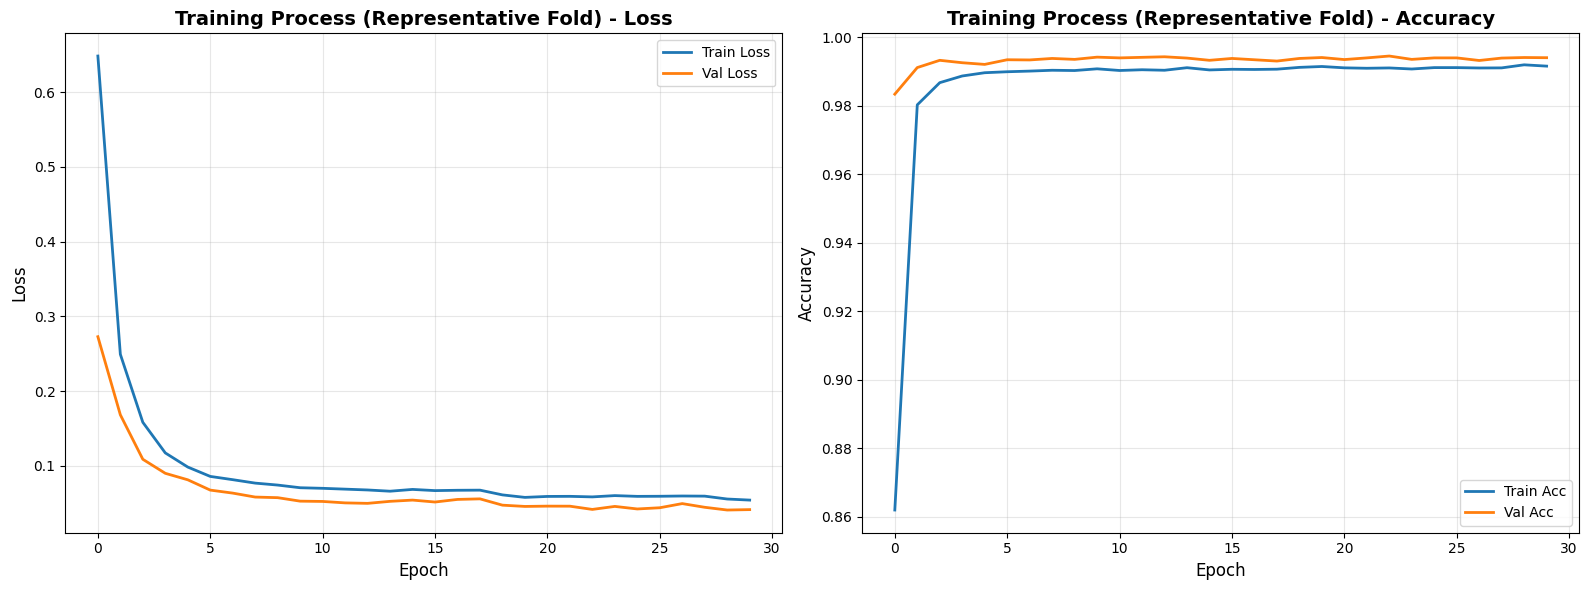


Classification Report:
              precision    recall  f1-score   support

    ENHANCER     1.0000    0.9830    0.9914      5419
    PROMOTER     0.9945    1.0000    0.9972      5420
  INTERGENIC     0.9887    1.0000    0.9943      5420

    accuracy                         0.9943     16259
   macro avg     0.9944    0.9943    0.9943     16259
weighted avg     0.9944    0.9943    0.9943     16259



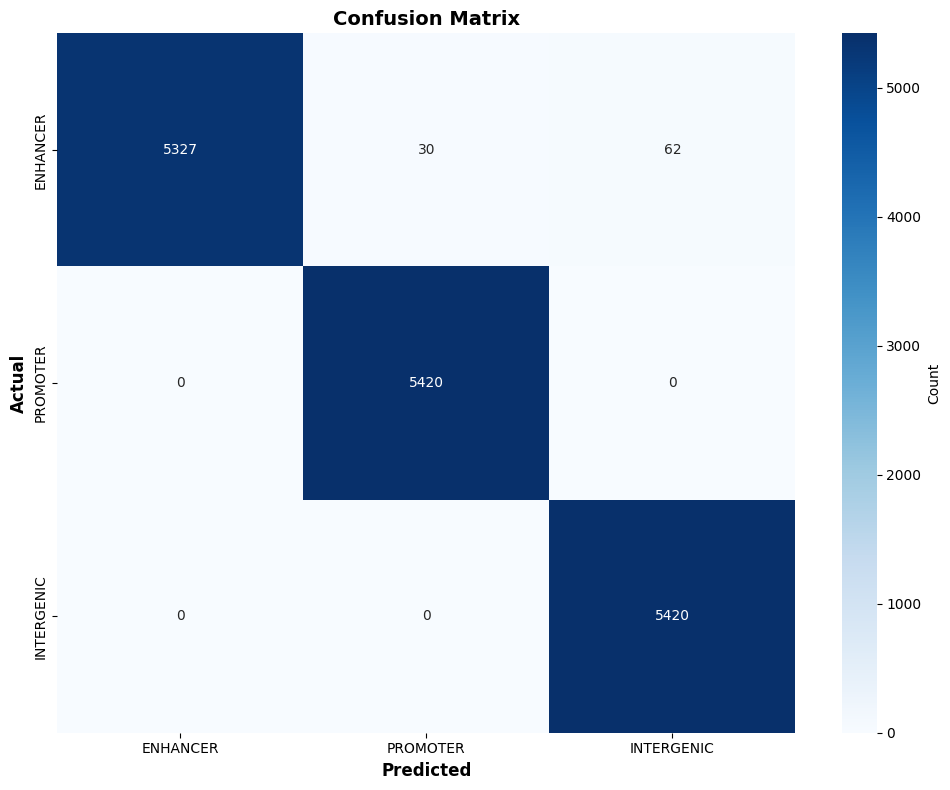

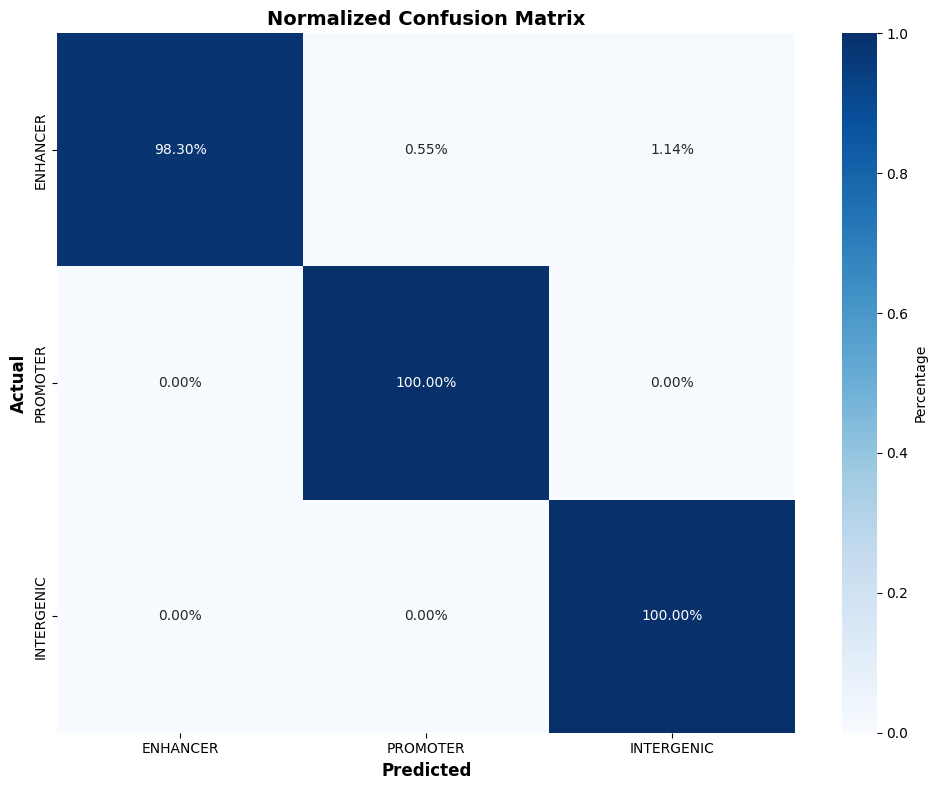


Per-Class Accuracy Analysis:
  ENHANCER: 98.30% (5419 samples)
  PROMOTER: 100.00% (5420 samples)
  INTERGENIC: 100.00% (5420 samples)

Sample Predictions (Random Sample):
  ✓ True: PROMOTER     | Predicted: PROMOTER     | Confidence: 99.73%
  ✓ True: PROMOTER     | Predicted: PROMOTER     | Confidence: 99.90%
  ✓ True: ENHANCER     | Predicted: ENHANCER     | Confidence: 100.00%
  ✓ True: PROMOTER     | Predicted: PROMOTER     | Confidence: 99.75%
  ✓ True: PROMOTER     | Predicted: PROMOTER     | Confidence: 99.85%
  ✓ True: PROMOTER     | Predicted: PROMOTER     | Confidence: 99.91%
  ✓ True: PROMOTER     | Predicted: PROMOTER     | Confidence: 99.65%
  ✓ True: PROMOTER     | Predicted: PROMOTER     | Confidence: 99.69%
  ✓ True: PROMOTER     | Predicted: PROMOTER     | Confidence: 99.86%
  ✓ True: ENHANCER     | Predicted: ENHANCER     | Confidence: 100.00%


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

print(f"--- Final Evaluation using the BEST Model found in CV ---")

# 1. Evaluate on test set using the BEST model found during CV
test_results = best_model.evaluate(X_test_ohe, y_test_cat, verbose=0)

# Create a dictionary of metrics
test_metrics = dict(zip(best_model.metrics_names, test_results))

# הדפסת עזר כדי לראות אילו מפתחות באמת קיימים (למקרה של דיבאג עתידי)
print(f"Available metrics keys: {list(test_metrics.keys())}")

print(f"\nTest Results:")
print(f"  Loss:      {test_metrics['loss']:.4f}")

# --- תיקון לשליפת ה-Accuracy ---
# חיפוש דינמי של המפתח הנכון (accuracy / acc / categorical_accuracy)
acc_key = next((k for k in test_metrics.keys() if 'acc' in k), None)

if acc_key:
    print(f"  Accuracy:  {test_metrics[acc_key]:.4f}")
else:
    print("  Accuracy:  N/A (Could not find accuracy metric)")

if 'auc' in test_metrics:
    print(f"  AUC:       {test_metrics['auc']:.4f}")

# 2. Make predictions
print("\nGenerating predictions...")
predictions = best_model.predict(X_test_ohe, verbose=0)
predicted_classes = predictions.argmax(axis=1)
y_test_classes = y_test_cat.argmax(axis=1)

# 3. Plot training history (Of the LAST Fold)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# בדיקה שההיסטוריה קיימת לפני הציור
if 'loss' in history.history:
    # Loss
    axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training Process (Representative Fold) - Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # Accuracy - חיפוש המפתח הנכון בהיסטוריה גם כן
    hist_acc_key = next((k for k in history.history.keys() if 'acc' in k and 'val' not in k), None)
    hist_val_acc_key = next((k for k in history.history.keys() if 'val_' in k and 'acc' in k), None)
    
    if hist_acc_key and hist_val_acc_key:
        axes[1].plot(history.history[hist_acc_key], label='Train Acc', linewidth=2)
        axes[1].plot(history.history[hist_val_acc_key], label='Val Acc', linewidth=2)
        axes[1].set_xlabel('Epoch', fontsize=12)
        axes[1].set_ylabel('Accuracy', fontsize=12)
        axes[1].set_title('Training Process (Representative Fold) - Accuracy', fontsize=14, fontweight='bold')
        axes[1].legend(fontsize=10)
        axes[1].grid(True, alpha=0.3)
else:
    print("Warning: No training history available to plot.")

plt.tight_layout()
plt.show()

# 4. Classification Report
class_names = ['ENHANCER', 'PROMOTER', 'INTERGENIC']

print("\nClassification Report:")
print(classification_report(
    y_test_classes, 
    predicted_classes,
    target_names=class_names,
    digits=4
))

# 5. Confusion Matrix
cm = confusion_matrix(y_test_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Count'}
)
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt='.2%', 
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Percentage'}
)
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 7. Per-class performance analysis
print("\nPer-Class Accuracy Analysis:")
for i, class_name in enumerate(class_names):
    class_mask = (y_test_classes == i)
    if class_mask.sum() > 0:
        class_acc = (predicted_classes[class_mask] == i).sum() / class_mask.sum()
        print(f"  {class_name}: {class_acc:.2%} ({class_mask.sum()} samples)")
    else:
        print(f"  {class_name}: No samples in test set")

# 8. Show some example predictions
print("\nSample Predictions (Random Sample):")
random_indices = np.random.choice(len(predicted_classes), 10, replace=False)
for i in random_indices:
    true_class = class_names[y_test_classes[i]]
    pred_class = class_names[predicted_classes[i]]
    confidence = predictions[i][predicted_classes[i]]
    match = "✓" if y_test_classes[i] == predicted_classes[i] else "✗"
    print(f"  {match} True: {true_class:12s} | Predicted: {pred_class:12s} | Confidence: {confidence:.2%}")


--- Final Comparison: SVM vs. CNN (Held-out Test Set) ---
Training SVM on full training data...


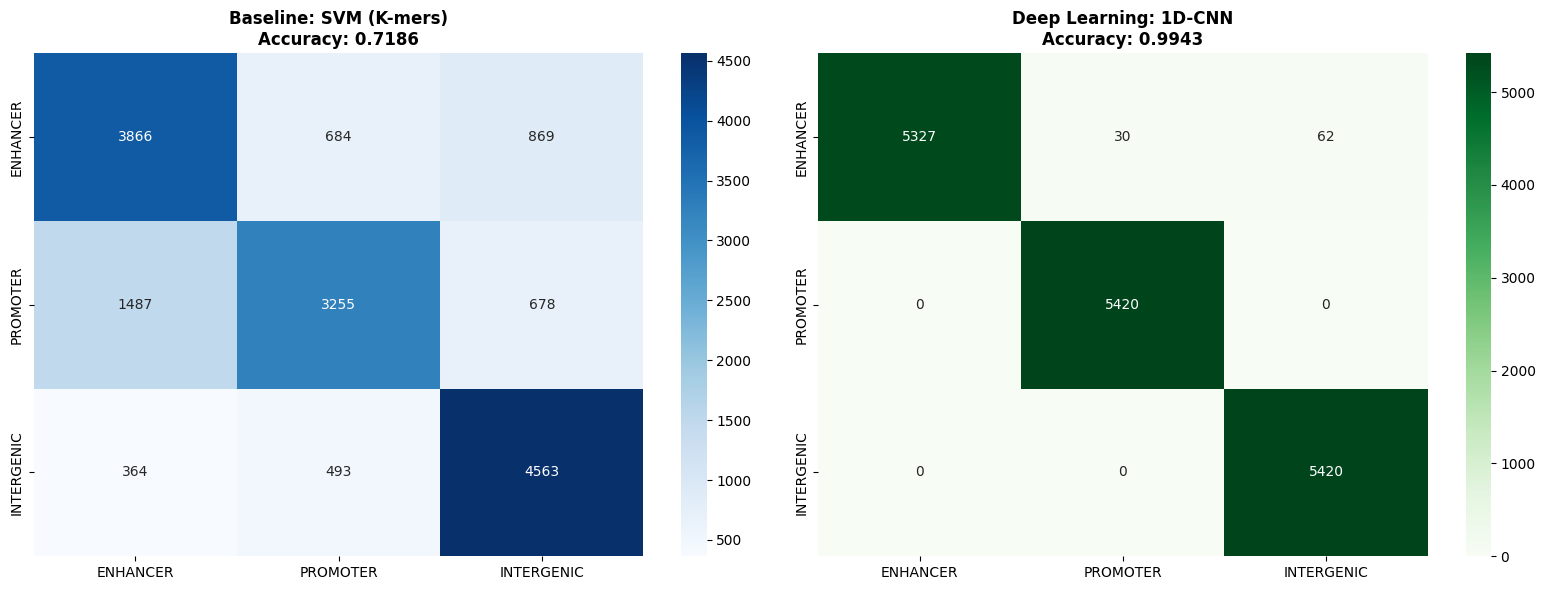


Final Result Summary:
SVM Accuracy: 71.86%
CNN Accuracy: 99.43%
Improvement:  +38.37%

--- Detailed Report (CNN) ---
              precision    recall  f1-score   support

    ENHANCER     1.0000    0.9830    0.9914      5419
    PROMOTER     0.9945    1.0000    0.9972      5420
  INTERGENIC     0.9887    1.0000    0.9943      5420

    accuracy                         0.9943     16259
   macro avg     0.9944    0.9943    0.9943     16259
weighted avg     0.9944    0.9943    0.9943     16259



In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n--- Final Comparison: SVM vs. CNN (Held-out Test Set) ---")

# 1. הכנת הנתונים ל-SVM (שימוש ב-K-mers כפי שהוגדר במקור)
# אנו משתמשים ב-X_train ו-X_test הגולמיים (רצפי אותיות) שהוגדרו בהתחלה
# הערה: עלינו לאמן את ה-SVM מחדש על כל ה-Train+Val כדי שיהיה הוגן מול ה-CNN
print("Training SVM on full training data...")
X_train_full_raw = X_train + X_val  # איחוד רשימות
y_train_full = np.concatenate([y_train, y_val])

# וקטוריזציה (K-mers) - בהנחה ששמרת את הפרמטרים הטובים מה-Optuna
# אם לא, נשתמש בברירת מחדל סבירה (למשל K=4 או 5)
k_mer_size = 5 # או המספר שמצאת ב-Optuna
vectorizer = CountVectorizer(analyzer='char', ngram_range=(k_mer_size, k_mer_size))
X_train_vec = vectorizer.fit_transform(X_train_full_raw)
X_test_vec = vectorizer.transform(X_test) # המרת ה-Test Set

# אימון SVM
svm_model = LinearSVC(C=1.0, max_iter=2000, dual="auto") # C=1.0 או הערך מ-Optuna
svm_model.fit(X_train_vec, y_train_full)

# חיזוי SVM
y_pred_svm = svm_model.predict(X_test_vec)
acc_svm = accuracy_score(y_test, y_pred_svm)

# 2. קבלת התחזיות מה-CNN (המודל הטוב ביותר מה-CV)
# X_test_ohe הוכן בתאים הקודמים
y_pred_cnn_probs = best_model.predict(X_test_ohe, verbose=0)
y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1)
acc_cnn = accuracy_score(y_test, y_pred_cnn)

# 3. ויזואליזציה - מטריצות בלבול
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labels = ['ENHANCER', 'PROMOTER', 'INTERGENIC']

# SVM Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title(f'Baseline: SVM (K-mers)\nAccuracy: {acc_svm:.4f}', fontsize=12, fontweight='bold')

# CNN Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_cnn), annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title(f'Deep Learning: 1D-CNN\nAccuracy: {acc_cnn:.4f}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 4. סיכום טקסטואלי
print(f"\nFinal Result Summary:")
print(f"SVM Accuracy: {acc_svm:.2%}")
print(f"CNN Accuracy: {acc_cnn:.2%}")
improvement = (acc_cnn - acc_svm) / acc_svm * 100
print(f"Improvement:  {improvement:+.2f}%")

print("\n--- Detailed Report (CNN) ---")
print(classification_report(y_test, y_pred_cnn, target_names=labels, digits=4))


--- Model Interpretability Analysis ---
Visualizing weights from layer: conv1d_36


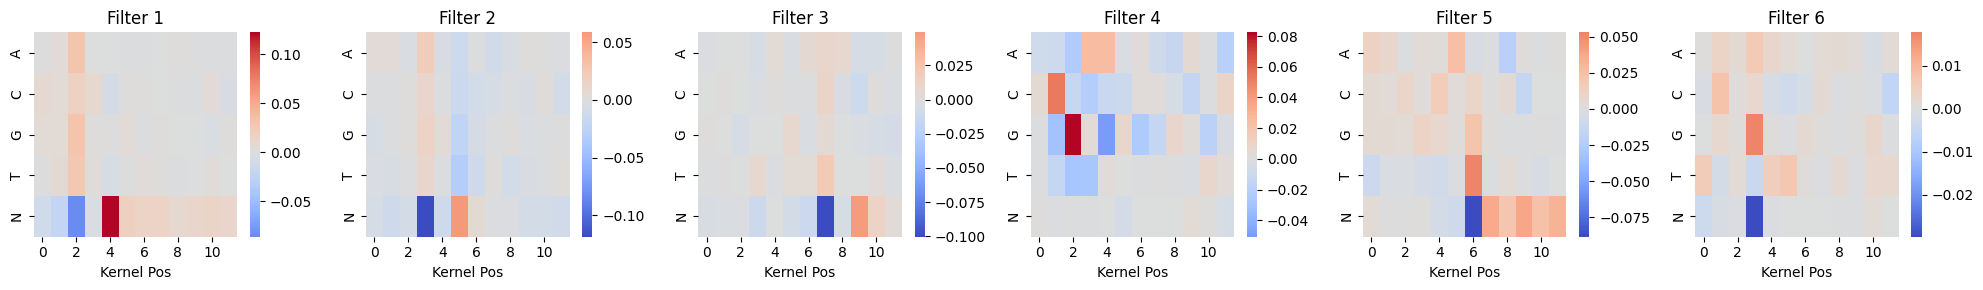

Generating Saliency Map for sample 10 (Class: ENHANCER)...


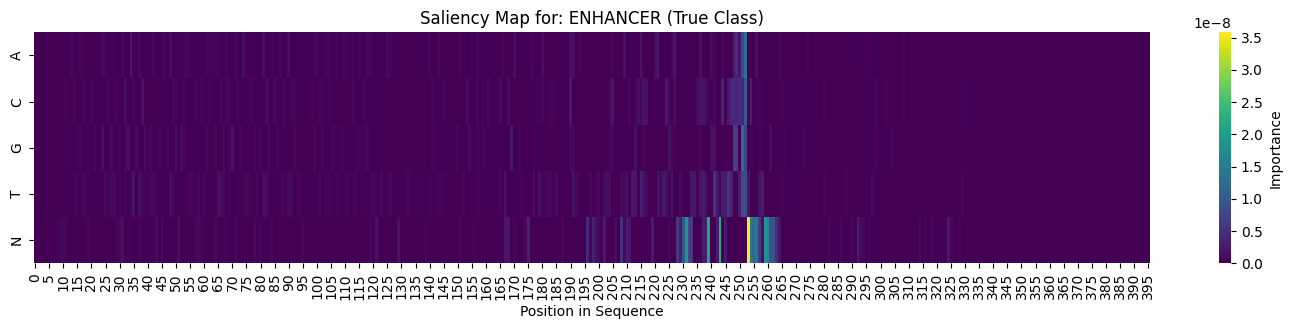

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_saliency_map(model, seq_ohe, true_label_idx, id2label_map):
    """
    מייצר מפת חום המראה אילו נוקלאוטידים השפיעו הכי הרבה על ההחלטה
    """
    # המרת הרצף ל-Tensor (Batch size = 1)
    input_tensor = tf.convert_to_tensor([seq_ohe], dtype=tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(input_tensor)
        preds = model(input_tensor)
        # אנו מתמקדים בציון שנתן המודל למחלקה האמיתית
        loss = preds[0][true_label_idx]
        
    # חישוב הנגזרת (Gradients) של הציון ביחס לקלט
    grads = tape.gradient(loss, input_tensor)[0].numpy()
    
    # נרמול להצגה (לוקחים רק תרומה חיובית - ReLU) - מה ש"הדליק" את הנוירון
    grads = np.maximum(grads, 0)
    
    # ויזואליזציה
    plt.figure(figsize=(18, 3))
    # Transpose כדי שהבסיסים (ACGTN) יהיו בציר ה-Y
    sns.heatmap(grads.T, cmap="viridis", yticklabels=['A','C','G','T','N'], cbar_kws={'label': 'Importance'})
    plt.title(f"Saliency Map for: {id2label_map[true_label_idx]} (True Class)")
    plt.xlabel("Position in Sequence")
    plt.show()

def visualize_first_layer_filters(model):
    """
    מציג את המשקולות של הפילטרים בשכבה הראשונה.
    פילטרים אלו לרוב מייצגים מוטיבים ביולוגיים.
    """
    # מציאת השכבה הקונבולוציונית הראשונה
    conv_layers = [layer for layer in model.layers if 'conv1d' in layer.name]
    if not conv_layers:
        print("No Conv1D layers found.")
        return
    
    first_conv = conv_layers[0]
    weights = first_conv.get_weights()[0] # Shape: (kernel_size, input_channels, filters)
    
    # בחירת מספר פילטרים להצגה
    n_filters_to_show = min(6, weights.shape[2])
    fig, axes = plt.subplots(1, n_filters_to_show, figsize=(20, 3))
    
    print(f"Visualizing weights from layer: {first_conv.name}")
    for i in range(n_filters_to_show):
        # שליפת הפילטר ה-i
        w = weights[:, :, i] 
        sns.heatmap(w.T, ax=axes[i], cmap="coolwarm", center=0, yticklabels=['A','C','G','T','N'])
        axes[i].set_title(f"Filter {i+1}")
        axes[i].set_xlabel("Kernel Pos")
    
    plt.tight_layout()
    plt.show()

# --- הרצת ניתוח הפרשנות ---
print("\n--- Model Interpretability Analysis ---")

# 1. הצגת פילטרים (מה המודל מחפש בגדול?)
visualize_first_layer_filters(best_model)

# 2. מפת חום לרצף ספציפי (למה הוא סיווג דוגמה ספציפית כ-Promoter?)
# לוקחים דוגמה אקראית מסט הולידציה האחרון
sample_idx = 10  # אתה יכול לשנות אינדקס זה כדי לראות רצפים אחרים
sample_seq = X_test_ohe[sample_idx] 
sample_label = y_test[sample_idx]

print(f"Generating Saliency Map for sample {sample_idx} (Class: {ID2LABEL[sample_label]})...")
plot_saliency_map(best_model, sample_seq, sample_label, ID2LABEL)

In [ ]:
# model.save('dna_cnn_model.keras')